<a href="https://colab.research.google.com/github/Linda95141/Loan_interest_rate/blob/main/Loan_Interest_Rate.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Introduction**

The objective of this report is to analyse and examine how interest rate determinants influence the consumer credit market with available data from Lending Club, a lending peer-to-peer platform. The available dataset contains 10,000 loan observations with a distincted loan and borrower characteristics with diverse variables such as verified income, credit performance metrics, employment history, debt-to-income ratio, etc. The main purpose of analysing this dataset is to be able to identify the borrower and their attributed loan to gain a better understanding of the risk associated with credit and implement the right pricing mechanism tailored to the consumer

**1. Part A: Data Preparation**

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import statsmodels.api as sm

In [3]:
df = pd.read_csv("loans_dataset.csv")
df.head()

,emp_title,emp_length,state,homeownership,annual_income,verified_income,debt_to_income,annual_income_joint,verification_income_joint,debt_to_income_joint,...,sub_grade,issue_month,loan_status,initial_listing_status,disbursement_method,balance,paid_total,paid_principal,paid_interest,paid_late_fees
0,global config engineer,3.0,NJ,MORTGAGE,90000.0,Verified,18.01,NaN,NaN,NaN,...,C3,Mar-2018,Current,whole,Cash,27015.86,1999.33,984.14,1015.19,0.0
1,warehouse office clerk,10.0,HI,RENT,40000.0,Not Verified,5.04,NaN,NaN,NaN,...,C1,Feb-2018,Current,whole,Cash,4651.37,499.12,348.63,150.49,0.0
2,assembly,3.0,WI,RENT,40000.0,Source Verified,21.15,NaN,NaN,NaN,...,D1,Feb-2018,Current,fractional,Cash,1824.63,281.80,175.37,106.43,0.0
3,customer service,1.0,PA,RENT,30000.0,Not Verified,10.16,NaN,NaN,NaN,...,A3,Jan-2018,Current,whole,Cash,18853.26,3312.89,2746.74,566.15,0.0
4,security supervisor,10.0,CA,RENT,35000.0,Verified,57.96,57000.0,Verified,37.66,...,C3,Mar-2018,Current,whole,Cash,21430.15,2324.65,1569.85,754.80,0.0


**store original number of observations**

In [4]:
original_rows = df.shape[0]
original_columns = df.shape[1]

**1.1 Variable selection and Cleaning**

**(a) Retained variables**

In [5]:
retained_variables = [
    "interest_rate",
    "verified_income",
    "debt_to_income",
    "total_credit_utilized",
    "total_credit_limit",
    "public_record_bankrupt",
    "loan_purpose",
    "term",
    "inquiries_last_12m",
    "issue_month",
    "annual_income",
    "loan_amount",
    "grade",
    "emp_length",
    "homeownership"
]

In [6]:
clean_df = df[retained_variables]
clean_df.head()

,interest_rate,verified_income,debt_to_income,total_credit_utilized,total_credit_limit,public_record_bankrupt,loan_purpose,term,inquiries_last_12m,issue_month,annual_income,loan_amount,grade,emp_length,homeownership
0,14.07,Verified,18.01,38767,70795,0,moving,60,6,Mar-2018,90000.0,28000,C,3.0,MORTGAGE
1,12.61,Not Verified,5.04,4321,28800,1,debt_consolidation,36,1,Feb-2018,40000.0,5000,C,10.0,RENT
2,17.09,Source Verified,21.15,16000,24193,0,other,36,4,Feb-2018,40000.0,2000,D,3.0,RENT
3,6.72,Not Verified,10.16,4997,25400,0,debt_consolidation,36,0,Jan-2018,30000.0,21600,A,1.0,RENT
4,14.07,Verified,57.96,52722,69839,0,credit_card,36,7,Mar-2018,35000.0,23000,C,10.0,RENT


In [ ]:
# create a comparison table

In [99]:
dataset_comparison = pd.DataFrame({
    'Original Dataset': [original_rows, original_columns],
    'Cleaned Dataset': [clean_df.shape[0], clean_df.shape[1]]
}, index=['Rows', 'Columns'])
print(dataset_comparison)
plt.show()

         Original Dataset  Cleaned Dataset
Rows                10000            10000
Columns                55               17


In [100]:
html = dataset_comparison.to_html()
with open('retained variables.html', 'w') as f:f.write(html)

In [7]:
html = clean_df.head().to_html()
with open('clean_variables.html', 'w') as f:f.write(html)

**(b) Rename Columns**

In [8]:
clean_df = clean_df.rename(columns={"inquiries_last_12m": "credit_checks"})
clean_df.head()

,interest_rate,verified_income,debt_to_income,total_credit_utilized,total_credit_limit,public_record_bankrupt,loan_purpose,term,credit_checks,issue_month,annual_income,loan_amount,grade,emp_length,homeownership
0,14.07,Verified,18.01,38767,70795,0,moving,60,6,Mar-2018,90000.0,28000,C,3.0,MORTGAGE
1,12.61,Not Verified,5.04,4321,28800,1,debt_consolidation,36,1,Feb-2018,40000.0,5000,C,10.0,RENT
2,17.09,Source Verified,21.15,16000,24193,0,other,36,4,Feb-2018,40000.0,2000,D,3.0,RENT
3,6.72,Not Verified,10.16,4997,25400,0,debt_consolidation,36,0,Jan-2018,30000.0,21600,A,1.0,RENT
4,14.07,Verified,57.96,52722,69839,0,credit_card,36,7,Mar-2018,35000.0,23000,C,10.0,RENT


In [9]:
html = clean_df.head().to_html()
with open('rename_columns.html', 'w') as f:f.write(html)

**(C) Documentation**

**Number of observation**

In [10]:
clean_rows = clean_df.shape[0]

In [11]:
print("Number of obervations before cleaning:", original_rows)
print("Number of observations after clean:", clean_rows)

Number of obervations before cleaning: 10000
Number of observations after clean: 10000


In [12]:
html = f"Number of obervations before cleaning: {original_rows}<br>Number of observations after clean: {clean_rows}"
with open('Number of observation.html', 'w') as f:f.write(html)

**Summary Statistics**

In [13]:
print('summary statistics for cleaned numerical variables:')
print(clean_df.describe().round(2))
plt.show()

summary statistics for cleaned numerical variables:
       interest_rate  debt_to_income  total_credit_utilized  \
count       10000.00         9976.00               10000.00   
mean           12.43           19.31               51049.06   
std             5.00           15.00               53636.73   
min             5.31            0.00                   0.00   
25%             9.43           11.06               19185.50   
50%            11.98           17.57               36927.00   
75%            15.05           25.00               65421.00   
max            30.94          469.09              942456.00   

       total_credit_limit  public_record_bankrupt      term  credit_checks  \
count            10000.00                10000.00  10000.00       10000.00   
mean            183606.23                    0.12     43.27           1.96   
std             187632.71                    0.34     11.03           2.38   
min                  0.00                    0.00     36.00         

In [14]:
html = clean_df.describe().round(2).to_html()
with open('summary statistics.html', 'w') as f:f.write(html)

**2. Part B: Exploratory Data Analysis (EDA)**

**2.1 Descriptive Statistics**

**(a) Calculate the mean, median, standard deviation, minimun and maximum**



In [15]:
import matplotlib.pyplot as plt

In [16]:
var_stats = ["interest_rate", "annual_income", "debt_to_income", "loan_amount"]


In [17]:
desc_table = df[var_stats].agg(["mean", "median", "std", "min", "max"]).T


In [18]:
print(desc_table.round(2))
plt.show()

                    mean    median       std      min         max
interest_rate      12.43     11.98      5.00     5.31       30.94
annual_income   79222.15  65000.00  64734.29     0.00  2300000.00
debt_to_income     19.31     17.57     15.00     0.00      469.09
loan_amount     16361.92  14500.00  10301.96  1000.00    40000.00


In [19]:
html = desc_table.round(2).to_html()
with open('calculate the mean, median, standard deviation, minimun and maximum.html', 'w') as f:f.write(html)

**(b) Count of Unique Categories**

In [20]:
categorical_vars = ["grade", "verified_income", "homeownership"]

In [21]:
freq = df[categorical_vars].value_counts()
percent = df[categorical_vars].value_counts(normalize=True)*100


In [22]:
cat_table = pd.DataFrame({"count": freq, "percentage": percent.round(2)})

In [23]:
print(cat_table)



                                     count  percentage
grade verified_income homeownership                   
B     Source Verified MORTGAGE         659        6.59
A     Not Verified    MORTGAGE         587        5.87
C     Source Verified MORTGAGE         544        5.44
B     Not Verified    MORTGAGE         516        5.16
C     Source Verified RENT             498        4.98
...                                    ...         ...
F     Not Verified    OWN                1        0.01
G     Source Verified MORTGAGE           1        0.01
                      RENT               1        0.01
      Verified        OWN                1        0.01
                      RENT               1        0.01

[61 rows x 2 columns]


In [24]:
html = cat_table.to_html()
with open('count of unique categories.html', 'w') as f:f.write(html)

**2.2 Visualizations**

**(a) Histograms**

In [25]:
# histogram for distribution of interest rate

In [26]:
import seaborn as sns

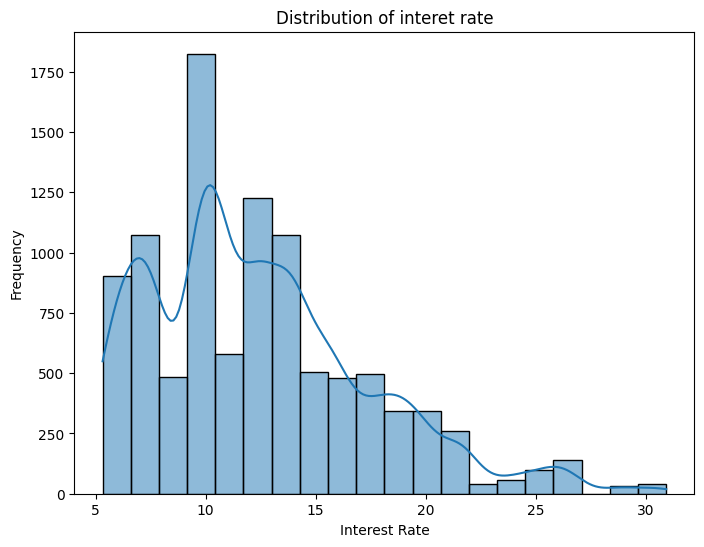

In [27]:
plt.figure(figsize=(8, 6))
sns.histplot(clean_df['interest_rate'], bins=20, kde=True)
plt.title('Distribution of interet rate')
plt.xlabel('Interest Rate')
plt.ylabel('Frequency')
plt.savefig('distribution of interest rate.png')
plt.show()

In [28]:
# Histogram for Distribution of annual income

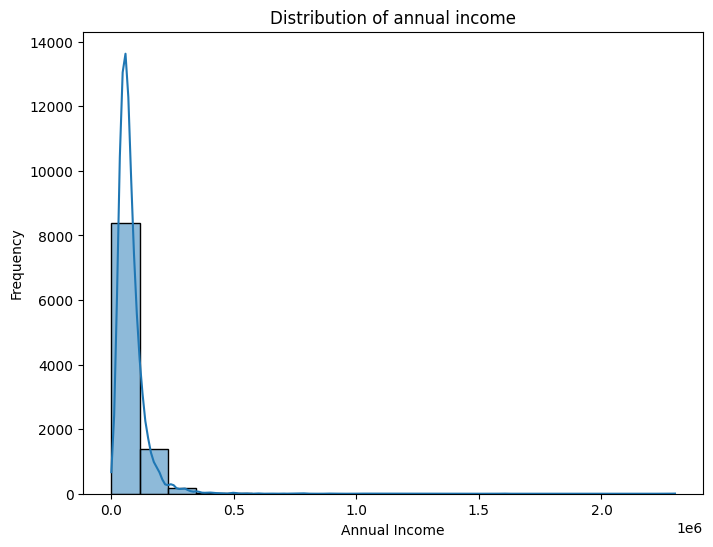

In [29]:
plt.figure(figsize=(8, 6))
sns.histplot(clean_df['annual_income'], bins=20, kde=True)
plt.title('Distribution of annual income')
plt.xlabel('Annual Income')
plt.ylabel('Frequency')
plt.savefig('distribution of annual income.png')
plt.show()

**(b) Scatterplots**

In [30]:
# Scatterplots for interest rate vs annual income

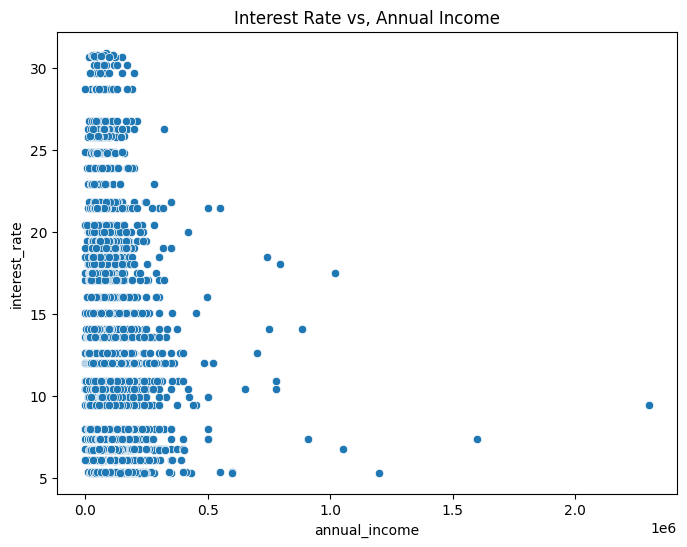

In [31]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=clean_df, x='annual_income', y='interest_rate')
plt.title('Interest Rate vs, Annual Income')
plt.savefig('interest rate vs annual income.png')
plt.show()

In [32]:
# scatterplot for interest rate vs debt to income

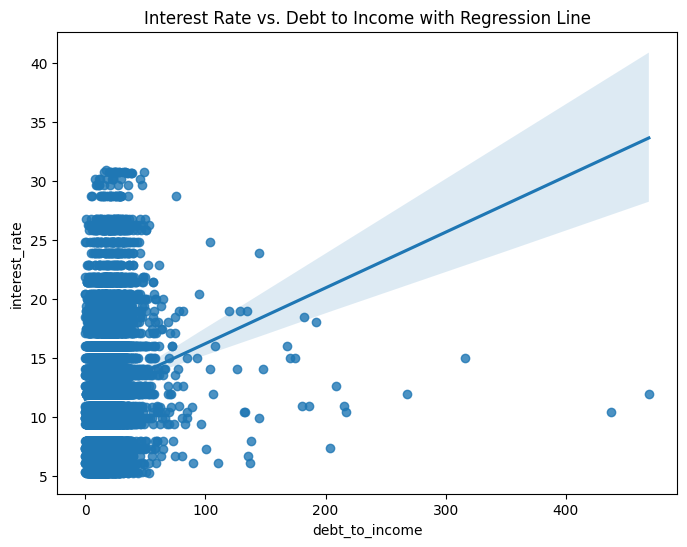

In [33]:
plt.figure(figsize=(8, 6))
sns.regplot(data=clean_df, x='debt_to_income', y='interest_rate')
plt.title('Interest Rate vs. Debt to Income with Regression Line')
plt.savefig('interest rate vs debt to income with regression line.png')
plt.show()

**(c) Boxplots**

In [34]:
# Boxplot for interest rate grouped by grade

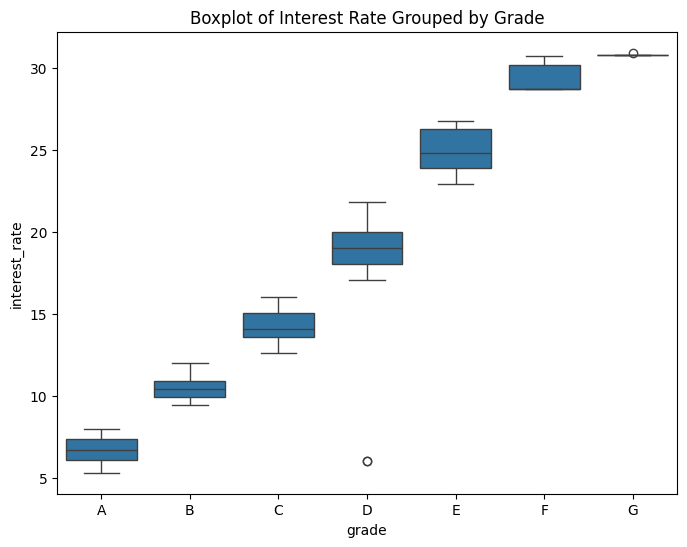

In [35]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=clean_df, x='grade', y='interest_rate', order=['A', 'B', 'C', 'D', 'E', 'F', 'G'])
plt.title('Boxplot of Interest Rate Grouped by Grade')
plt.savefig('Boxplot of interest rate grouped by grade.png')
plt.show()

In [36]:
# Boxplot for interest rate grouped by verified income

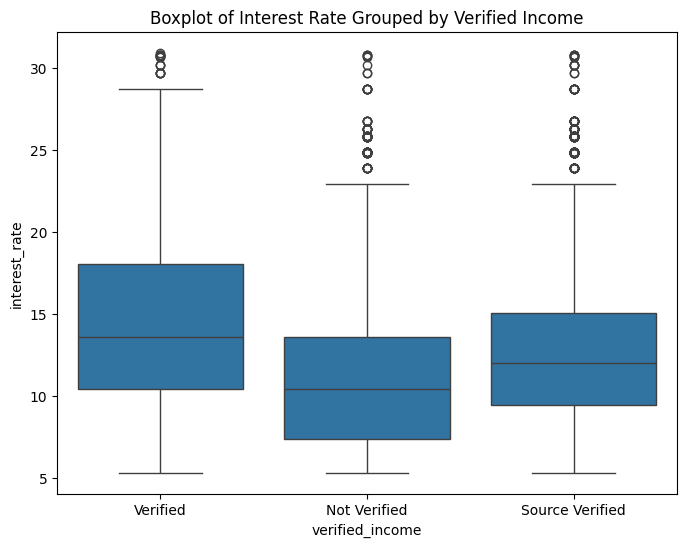

In [37]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=clean_df, x='verified_income', y='interest_rate')
plt.title('Boxplot of Interest Rate Grouped by Verified Income')
plt.savefig('Boxplot of interest rate grouped by veried income.png')
plt.show()

In [38]:
#boxplot for interest rate grouped by homeownership

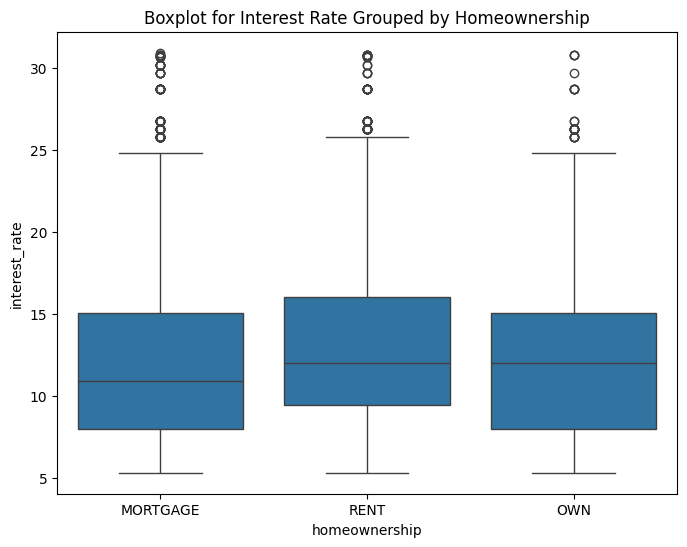

In [39]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=clean_df, x='homeownership', y='interest_rate')
plt.title('Boxplot for Interest Rate Grouped by Homeownership')
plt.savefig('Boxplot for interest rate grouped by homeownership.png')
plt.show()


**2.3 Featuring Engineering**

**(a) Credit Utilization Ratio (Credit_Util)**

credit_util = total_credit_utilized/total_credit_limit

Set to 0 where
Total_Credit_utilized = 0 and
Total_Credit_Limit = 0


In [40]:
import numpy as np

In [41]:
clean_df = pd.DataFrame(clean_df)

In [42]:
clean_df['credit_util'] = np.where(clean_df['total_credit_limit'] ==0,0,clean_df['total_credit_utilized'] / clean_df['total_credit_limit'])


In [43]:
# calculate Statistics

In [44]:
mean_credit_util = clean_df['credit_util'].mean()
percent_non_zero = (
    (clean_df['credit_util'] !=0).sum() /len(clean_df)
) *100

In [45]:
# create summary table

In [46]:
summary_table = pd.DataFrame({
   'Variable': ['credit_utili'],
   'Mean': [round(mean_credit_util, 3)],
   '% Non_Zero': [round(percent_non_zero, 2)]
})
print(summary_table)
plt.show()

       Variable   Mean  % Non_Zero
0  credit_utili  0.403       99.72


In [47]:
html = summary_table.to_html()
with open('credit utilization ratio.html', 'w') as f:f.write(html)

(b) **Bankruptcy Indicator ( bankruptcy_dummy)**

In [48]:
# create bankruptcy dummy

In [49]:
clean_df['bankruptcy_dummy'] = np.where(clean_df['public_record_bankrupt'] >=1, 1,0)

In [50]:
# calaculate Statistics

In [51]:
mean_bankruptcy =clean_df['bankruptcy_dummy'].mean()
percent_non_zero_bankruptcy = (
    (clean_df['bankruptcy_dummy'] !=0).sum() / len(clean_df)) *100

bankruptcy_table = pd.DataFrame({
    'Variable': ['bankruptcy_dummy'],
    'Mean': [round(mean_bankruptcy, 3)],
    '% Non_Zero': [round(percent_non_zero_bankruptcy, 2)]
})
print(bankruptcy_table)
plt.show()



           Variable   Mean  % Non_Zero
0  bankruptcy_dummy  0.122       12.15


In [52]:
html = bankruptcy_table.to_html()
with open('bankruptcy indicator.html', 'w') as f:f.write(html)

**Part C: Regression Analysis**

**3.1 Models**

(a) Model 1: Simple Linear Regression

interest_rate $= \beta_0+\beta_1$ debt to income $+ \varepsilon$


In [53]:
#select variables
df_model1 =clean_df[['interest_rate','debt_to_income']].dropna()

In [54]:
#define x (independent variable) and y(dependent variable)
X1 =sm.add_constant(df_model1['debt_to_income'])
y =df_model1['interest_rate']

In [55]:
#fit regression model
model1 = sm.OLS(y,X1).fit()
print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:          interest_rate   R-squared:                       0.020
Model:                            OLS   Adj. R-squared:                  0.020
Method:                 Least Squares   F-statistic:                     204.2
Date:                Fri, 15 May 2026   Prob (F-statistic):           7.05e-46
Time:                        12:55:39   Log-Likelihood:                -30105.
No. Observations:                9976   AIC:                         6.021e+04
Df Residuals:                    9974   BIC:                         6.023e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const             11.5114      0.081    142.

In [56]:
html = model1.summary().as_html()
with open('model1.html', 'w') as f:f.write(html)

In [57]:
!pip install Stargazer
from stargazer.stargazer import Stargazer

In [58]:
#regression table for model1
table1 = Stargazer([model1])
table1.rename_covariates({'Intercept':'Constant'})
table1.custom_columns(['Homoskedastic SE'],[1])
table1

In [59]:
html = table1.render_html()
with open('regression table for model1.html', 'w') as f:f.write(html)



*   Fitted Regression Equation




β0 =11.511





β1 =0.047

interest_rate=11.511+0.047 debt_to_income



*  Economic Interpretation of β1 Coefficient




The Coefficient β1 = 0.047

This coeficient means that for every 1 unit increase in debt_to_income ratio, there is an increase of interest rate of 0.047percentage point, indicating that borrowers with financial burden incure higher borrowing cost



*   Hypothesis Testing




A hypothesis test of H0:β1=0 has a P value close to zero which automatically reject H0 at 1%, 5%, and 10% indicating a significant relationship

**(b) Model 2: Simple Linear Regression**

In [60]:
import statsmodels.formula.api as smf

interest_rate$=\beta_0+\beta_1$ bankruptcy_dummy$+\varepsilon$

In [61]:
# create bankruptcy_dummy variable

In [62]:
clean_df['bankruptcy_dummy'] = np.where(clean_df['public_record_bankrupt'] >= 1, 1,0)

In [63]:
model2 = smf.ols('interest_rate ~ bankruptcy_dummy', data=clean_df).fit()
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:          interest_rate   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                  0.002
Method:                 Least Squares   F-statistic:                     23.22
Date:                Fri, 15 May 2026   Prob (F-statistic):           1.47e-06
Time:                        12:55:48   Log-Likelihood:                -30274.
No. Observations:               10000   AIC:                         6.055e+04
Df Residuals:                    9998   BIC:                         6.057e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept           12.3380      0.053  

In [64]:
html = model2.summary().as_html()
with open('model2.html', 'w') as f:f.write(html)

In [65]:
# regression table for model2

In [66]:
table2 = Stargazer([model2])
table2.rename_covariates({'Intercept': 'Constant'})
table2.custom_columns(['Homoskedastic SE'],[1])
table2

In [67]:
html = table2.render_html()
with open('regression table for model2.html', 'w') as f:f.write(html)

(c) Model 3: Categorical Variable Regression

$interest\_rate = \beta_0 +\beta_1D_1 + \beta_2D_2 + \varepsilon$

In [68]:
# create dummy variables for verified_income

In [69]:
clean_df['verified_income'].unique()

array(['Verified', 'Not Verified', 'Source Verified'], dtype=object)

In [70]:
model3 = smf.ols(
    "interest_rate ~ C(verified_income, Treatment(reference='Not Verified'))",
    data=clean_df
    ).fit()
print(model3.summary())

                            OLS Regression Results                            
Dep. Variable:          interest_rate   R-squared:                       0.059
Model:                            OLS   Adj. R-squared:                  0.059
Method:                 Least Squares   F-statistic:                     315.9
Date:                Fri, 15 May 2026   Prob (F-statistic):          8.92e-134
Time:                        12:55:48   Log-Likelihood:                -29979.
No. Observations:               10000   AIC:                         5.996e+04
Df Residuals:                    9997   BIC:                         5.999e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                                                                                 coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------

In [71]:
html = model3.summary().as_html()
with open('model3.html', 'w') as f:f.write(html)

In [72]:
# create a regression table for model3

In [73]:
table3 = Stargazer([model3])
table3.rename_covariates({'intercept':'Constant'})
table3.custom_columns(['Homoskedastic SE'], [1])
table3

In [74]:
html = table3.render_html()
with open('regression table for model3.html', 'w') as f:f.write(html)





*  Fitted Regression





Interest_rate = 11.099 + 1.460D1 +3.2543D2 + ɛ



*   Predicted average for reference category





The base case category = Not Verified Borrower

where



*   Dsourceverified =0
*   Dverified = 0




Interest rate = 11.099 + 1.460(0) + 3.2543(0)

Interest rate is therefore 11.099

Interpret

*   β1 = 1.460
means: source-verified borrowers pay 1.460 percentage points more than not verified borrowers

*   β2 = 3.2543
means: verified borrowers pay 3.2543 percentage points more than not verified borrowers







**(d) Model 4: Multiple Regression**

$interest\_rate = \beta_0 + \beta_1 debt\_to\_income + \beta_2 credit\_util + \beta_3 bankruptcy\_dummy + \varepsilon$

In [75]:
# create the variables

In [76]:
clean_df['credit_util'] = np.where(clean_df['total_credit_limit'] ==0,0, clean_df['total_credit_utilized'] / clean_df['total_credit_limit'])

In [77]:
model4 = smf.ols(
    'interest_rate ~ debt_to_income + credit_util + bankruptcy_dummy', data=clean_df
).fit()
print(model4.summary())

                            OLS Regression Results                            
Dep. Variable:          interest_rate   R-squared:                       0.078
Model:                            OLS   Adj. R-squared:                  0.077
Method:                 Least Squares   F-statistic:                     279.9
Date:                Fri, 15 May 2026   Prob (F-statistic):          1.85e-174
Time:                        12:55:48   Log-Likelihood:                -29803.
No. Observations:                9976   AIC:                         5.961e+04
Df Residuals:                    9972   BIC:                         5.964e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept            9.8708      0.102  

In [78]:
html = model4.summary().as_html()
with open('model4.html', 'w') as f:f.write(html)

In [79]:
# create a regression table for model 4

In [80]:
table4 = Stargazer([model4])
table4.rename_covariates({'intercept': 'constant'})
table4.custom_columns(['Homoskedastic SE'],[1])
table4

In [81]:
html = table4.render_html()
with open('regression table for model4.html', 'w') as f:f.write(html)

In [82]:
# create a table for model 1, model 2, and model 4.

In [83]:
table = Stargazer([model1, model2, model4])
table.rename_covariates({'intercept': 'constant'})
table.custom_columns(['model 1', 'model 2', 'model 3'], [1,1,1])
table

In [84]:
html = table.render_html()
with open('table for model 1, model 2, and model 4.html', 'w') as f:f.write(html)

**(e) Model 5: Full Specification**

In [85]:
clean_df['bankruptcy_dummy'] = (clean_df['public_record_bankrupt']>0).astype(int)

In [86]:
clean_df['credit_util'] = np.where(clean_df['total_credit_limit']==0,0 , clean_df['total_credit_utilized'] / clean_df['total_credit_limit'])

In [87]:
clean_df[[
    'interest_rate',
    'debt_to_income',
    'credit_util',
    'bankruptcy_dummy',
    'annual_income',
    'loan_amount',
    'credit_checks',
    'term',
    'grade',
    'emp_length',
    'homeownership',
    'loan_purpose'
]].dropna()

,interest_rate,debt_to_income,credit_util,bankruptcy_dummy,annual_income,loan_amount,credit_checks,term,grade,emp_length,homeownership,loan_purpose
0,14.07,18.01,0.547595,0,90000.0,28000,6,60,C,3.0,MORTGAGE,moving
1,12.61,5.04,0.150035,1,40000.0,5000,1,36,C,10.0,RENT,debt_consolidation
2,17.09,21.15,0.661348,0,40000.0,2000,4,36,D,3.0,RENT,other
3,6.72,10.16,0.196732,0,30000.0,21600,0,36,A,1.0,RENT,debt_consolidation
4,14.07,57.96,0.754908,0,35000.0,23000,7,36,C,10.0,RENT,credit_card
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,7.35,22.28,0.391390,1,108000.0,24000,5,36,A,10.0,RENT,other
9996,19.03,32.38,0.265850,0,121000.0,10000,1,36,D,8.0,MORTGAGE,debt_consolidation
9997,23.88,45.26,0.275463,0,67000.0,30000,0,36,E,10.0,MORTGAGE,debt_consolidation
9998,5.32,11.99,0.093865,0,80000.0,24000,1,36,A,1.0,MORTGAGE,other


In [88]:
html = clean_df.to_html()
with open('clean_df.html', 'w') as f:f.write(html)

In [89]:
model5 = smf.ols(
    '''
    interest_rate ~ debt_to_income
    + credit_util
    + bankruptcy_dummy
    + annual_income
    + loan_amount
    + C(term)
    + C(grade)
    + C(emp_length)
    + C(homeownership)
    + C(loan_purpose)
    + credit_checks
    ''',
    data=clean_df).fit()
print(model5.summary())

                            OLS Regression Results                            
Dep. Variable:          interest_rate   R-squared:                       0.952
Model:                            OLS   Adj. R-squared:                  0.952
Method:                 Least Squares   F-statistic:                     5042.
Date:                Fri, 15 May 2026   Prob (F-statistic):               0.00
Time:                        12:55:55   Log-Likelihood:                -13870.
No. Observations:                9182   AIC:                         2.781e+04
Df Residuals:                    9145   BIC:                         2.808e+04
Df Model:                          36                                         
Covariance Type:            nonrobust                                         
                                            coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------

In [90]:
html = model5.summary().as_html()
with open('model5.html', 'w') as f:f.write(html)

In [91]:
# Extract first 5 residuals

In [92]:
residuals = model5.resid.head().round(2)
print(residuals)

0   -0.30
1   -1.41
2   -2.11
3    0.04
4   -0.33
dtype: float64


In [93]:
# create a model 5 regression table

In [94]:
table5 = Stargazer([model5])
table5.rename_covariates({'intercept': 'constant'})
table5.custom_columns(['Homoskedastic SE'], [1])
table5

In [95]:
html = table5.render_html()
with open('regression table for model5.html', 'w') as f:f.write(html)

**3.2 Reporting results**

In [96]:
# create columns for Model 1 through 5 (table 6)

In [97]:
table6 = Stargazer([model1, model2, model3, model4, model5])
table6.custom_columns(['Model 1', 'Model 2', 'Model 3', 'Model 4', 'Model 5'], [1, 1, 1, 1, 1])
table6.rename_covariates({
    'intercept': 'constant',
    'debt_to_income': 'Debt to income',
    'credit_util': 'Credit Utilisation',
    'bankruptcy_dummy': 'Bankruptcy Dummy',
    'annual_income': 'Annual Income',
    'loan_amount': 'Loan Amount',
    'credit_checks': 'Credit Checks'

})

table6.significance_levels([0.1, 0.05, 0.01])
table6.show_r2 = True
table6.show_adj_r2 = False
table6.show_f_statistic = True
table6.show_n = True
table6

In [98]:
html = table6.render_html()
with open('table for model 1 through 5.html', 'w') as f:f.write(html)